# Cafe Sales — Data Cleaning & Exploratory Data Analysis

This notebook cleans a messy cafe sales dataset (`dirty_cafe_sales.csv`) and then explores it.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Raw Data

In [2]:
df=pd.read_csv('/kaggle/input/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv')

## 3. Initial Inspection

The raw file has three different "missing" markers: real `NaN`, and the literal strings `"ERROR"` and `"UNKNOWN"`. We standardize all of them to `NaN` before anything else, so they don't silently corrupt later numeric or date conversions.

In [3]:
df.info()
print("\nDuplicate rows:", df.duplicated().sum())

placeholder_values = ["ERROR", "UNKNOWN", "", "nan", "NaN", "None"]
df = df.replace(placeholder_values, np.nan)

print("\nMissing values per column after standardizing placeholders:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB

Duplicate rows: 0

Missing values per column after standardizing placeholders:
Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


## 4. Fix Data Types

Numeric columns are currently text because of the placeholder strings; the date column needs parsing. `errors="coerce"` turns anything unparseable into `NaN` instead of crashing.

In [4]:
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

df[numeric_cols + ["Transaction Date"]].dtypes

Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Transaction Date    datetime64[ns]
dtype: object

## 5. Missingness Overview (Raw)

Counts and percentages of missing values per column, visualized as a bar chart, to gauge the scale of the problem before fixing it.

                  missing_count  missing_pct
Transaction ID                0         0.00
Item                        969         9.69
Quantity                    479         4.79
Price Per Unit              533         5.33
Total Spent                 502         5.02
Payment Method             3178        31.78
Location                   3961        39.61
Transaction Date            460         4.60


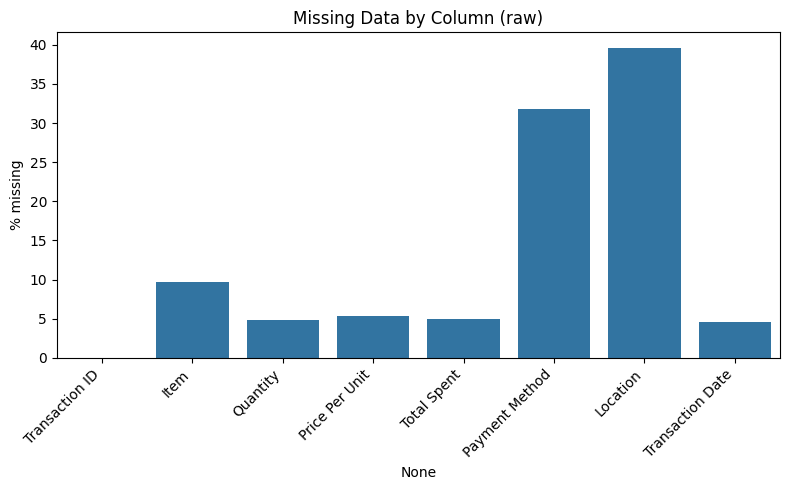

In [5]:
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": df.isna().sum(), "missing_pct": missing_pct})
print(missing_summary)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("% missing")
plt.title("Missing Data by Column (raw)")
plt.tight_layout()
plt.show()

## 6. Impute Numeric Values via `Quantity × Price = Total`

Since `Total Spent = Quantity * Price Per Unit`, if any two of the three are known, the third can always be computed. This recovers a large share of "missing" data with zero guessing.

In [6]:
# Recover Total Spent
mask = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[mask, "Total Spent"] = df.loc[mask, "Quantity"] * df.loc[mask, "Price Per Unit"]

# Recover Price Per Unit
mask = df["Price Per Unit"].isna() & df["Total Spent"].notna() & df["Quantity"].notna() & (df["Quantity"] != 0)
df.loc[mask, "Price Per Unit"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Quantity"]

# Recover Quantity
mask = df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna() & (df["Price Per Unit"] != 0)
df.loc[mask, "Quantity"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Price Per Unit"]

print("Missing numeric values remaining after cross-imputation:")
print(df[numeric_cols].isna().sum())

Missing numeric values remaining after cross-imputation:
Quantity          38
Price Per Unit    38
Total Spent       40
dtype: int64


## 7. Fill Remaining Prices via Item-Level Median

For rows still missing `Price Per Unit` but with a known `Item`, we assume the item's typical (median) price. Median is used over mean to stay robust to outliers. Total/Quantity are then re-derived using the newly filled prices.

In [7]:
item_price_median = df.groupby("Item")["Price Per Unit"].median()

def fill_price(row):
    if pd.isna(row["Price Per Unit"]) and pd.notna(row["Item"]):
        return item_price_median.get(row["Item"], np.nan)
    return row["Price Per Unit"]

df["Price Per Unit"] = df.apply(fill_price, axis=1)

# Recompute Total Spent / Quantity again now that some prices were filled
mask = df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()
df.loc[mask, "Total Spent"] = df.loc[mask, "Quantity"] * df.loc[mask, "Price Per Unit"]

mask = df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna() & (df["Price Per Unit"] != 0)
df.loc[mask, "Quantity"] = df.loc[mask, "Total Spent"] / df.loc[mask, "Price Per Unit"]

print("Missing numeric values remaining after item-median fill:")
print(df[numeric_cols].isna().sum())

Missing numeric values remaining after item-median fill:
Quantity          23
Price Per Unit     6
Total Spent       23
dtype: int64


## 8. Recover `Item` from Price Where Unambiguous

If `Item` is missing but `Price Per Unit` maps to exactly one item elsewhere in the data, we can safely infer it. If the price is shared by multiple items, it's left as `NaN` rather than guessed.

In [8]:
price_to_item = (
    df.dropna(subset=["Item", "Price Per Unit"])
      .groupby("Price Per Unit")["Item"]
      .agg(lambda s: s.mode().iat[0] if s.nunique() == 1 else np.nan)
)

def fill_item(row):
    if pd.isna(row["Item"]) and pd.notna(row["Price Per Unit"]):
        return price_to_item.get(row["Price Per Unit"], np.nan)
    return row["Item"]

df["Item"] = df.apply(fill_item, axis=1)

## 9. Handle Remaining Gaps

- `Item` / `Payment Method` / `Location`: unresolved values become an explicit `"Unknown"` category.
- `Transaction Date`: cannot be inferred from other columns, so rows without a date are dropped.
- Rows with **no** recoverable numeric data at all are dropped.

In [9]:
df["Item"] = df["Item"].fillna("Unknown")
df["Payment Method"] = df["Payment Method"].fillna("Unknown")
df["Location"] = df["Location"].fillna("Unknown")

before = len(df)
df = df.dropna(subset=["Transaction Date"])
print(f"Dropped {before - len(df)} rows with unrecoverable Transaction Date")

before = len(df)
df = df.dropna(subset=numeric_cols, how="all")
print(f"Dropped {before - len(df)} rows with no recoverable numeric data")

for col in numeric_cols:
    remaining = df[col].isna().sum()
    if remaining:
        print(f"{col}: {remaining} still missing -> filling with column median")
        df[col] = df[col].fillna(df[col].median())

Dropped 460 rows with unrecoverable Transaction Date
Dropped 0 rows with no recoverable numeric data
Quantity: 23 still missing -> filling with column median
Price Per Unit: 6 still missing -> filling with column median
Total Spent: 23 still missing -> filling with column median


## 10. Final Sanity Checks & Feature Engineering

Duplicates are removed, `Total Spent` is recomputed for full consistency, and `Month` / `Weekday` helper columns are derived from the date for later grouping. The cleaned data is saved to `cafe_sales_cleaned.csv`.

In [10]:
print("Remaining missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Recompute Total Spent everywhere for internal consistency
df["Total Spent"] = (df["Quantity"] * df["Price Per Unit"]).round(2)

df["Month"] = df["Transaction Date"].dt.to_period("M").astype(str)
df["Weekday"] = df["Transaction Date"].dt.day_name()

df.describe(include="all").T

Remaining missing values:
 Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Transaction ID,9540,9540,TXN_6170729,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,9540,9,Coffee,1246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,9540.0,NaN,NaN,NaN,3.021279,1.0,2.0,3.0,4.0,5.0,1.418458
Price Per Unit,9540.0,NaN,NaN,NaN,2.948637,1.0,2.0,3.0,4.0,5.0,1.278715
Total Spent,9540.0,NaN,NaN,NaN,8.920755,1.0,4.0,8.0,12.0,25.0,5.998162
Payment Method,9540,4,Unknown,3015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,9540,3,Unknown,3779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction Date,9540,NaN,NaN,NaN,2023-07-01 23:00:31.698113536,2023-01-01 00:00:00,2023-04-01 00:00:00,2023-07-02 00:00:00,2023-10-02 00:00:00,2023-12-31 00:00:00,NaN
Month,9540,12,2023-10,838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekday,9540,7,Friday,1388,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.to_csv("cafe_sales_cleaned.csv", index=False)
print("Saved cleaned dataset -> cafe_sales_cleaned.csv")
print("Final shape:", df.shape)

Saved cleaned dataset -> cafe_sales_cleaned.csv
Final shape: (9540, 10)


## 11. EDA — Overview & Descriptive Statistics

Basic `.describe()` calls on numeric and categorical columns to sanity-check the cleaned data before visualizing it.

In [12]:
df.info()
print("\nNumeric summary:\n", df[numeric_cols].describe())
print("\nCategorical summary:\n", df[["Item", "Payment Method", "Location", "Weekday"]].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    9540 non-null   object        
 1   Item              9540 non-null   object        
 2   Quantity          9540 non-null   float64       
 3   Price Per Unit    9540 non-null   float64       
 4   Total Spent       9540 non-null   float64       
 5   Payment Method    9540 non-null   object        
 6   Location          9540 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
 8   Month             9540 non-null   object        
 9   Weekday           9540 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 819.8+ KB

Numeric summary:
           Quantity  Price Per Unit  Total Spent
count  9540.000000     9540.000000  9540.000000
mean      3.021279        2.948637     8.920755
std       1.41

## 12. Univariate — Numeric Distributions

Histograms with KDE curves for Quantity, Price, and Total Spent, to see shape — skew, spread, multi-modality — at a glance.

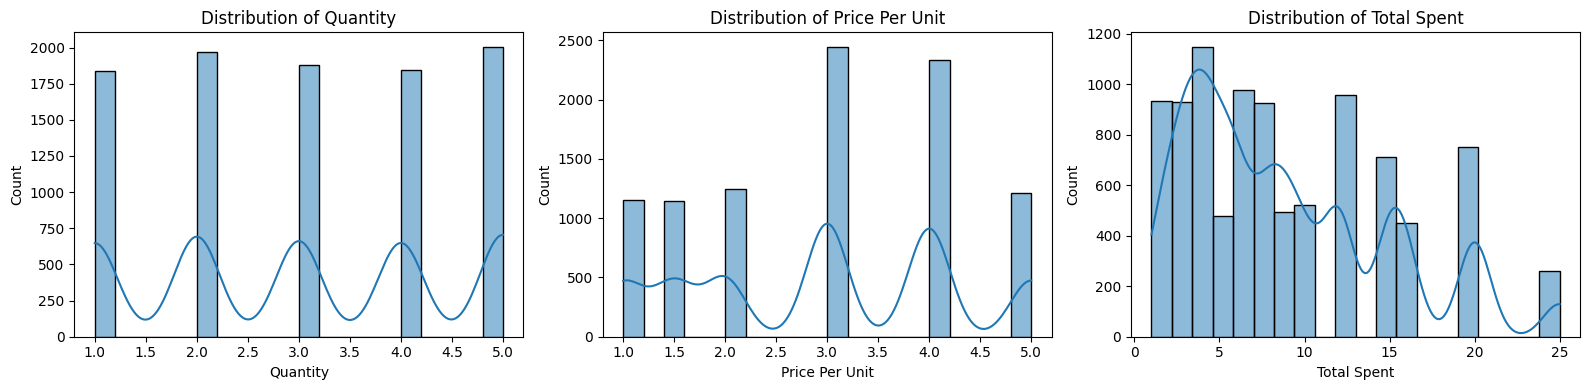

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=20)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## 13. Univariate — Categorical Distributions

Bar counts for Item, Payment Method, Location, and Weekday, showing which categories dominate the dataset.

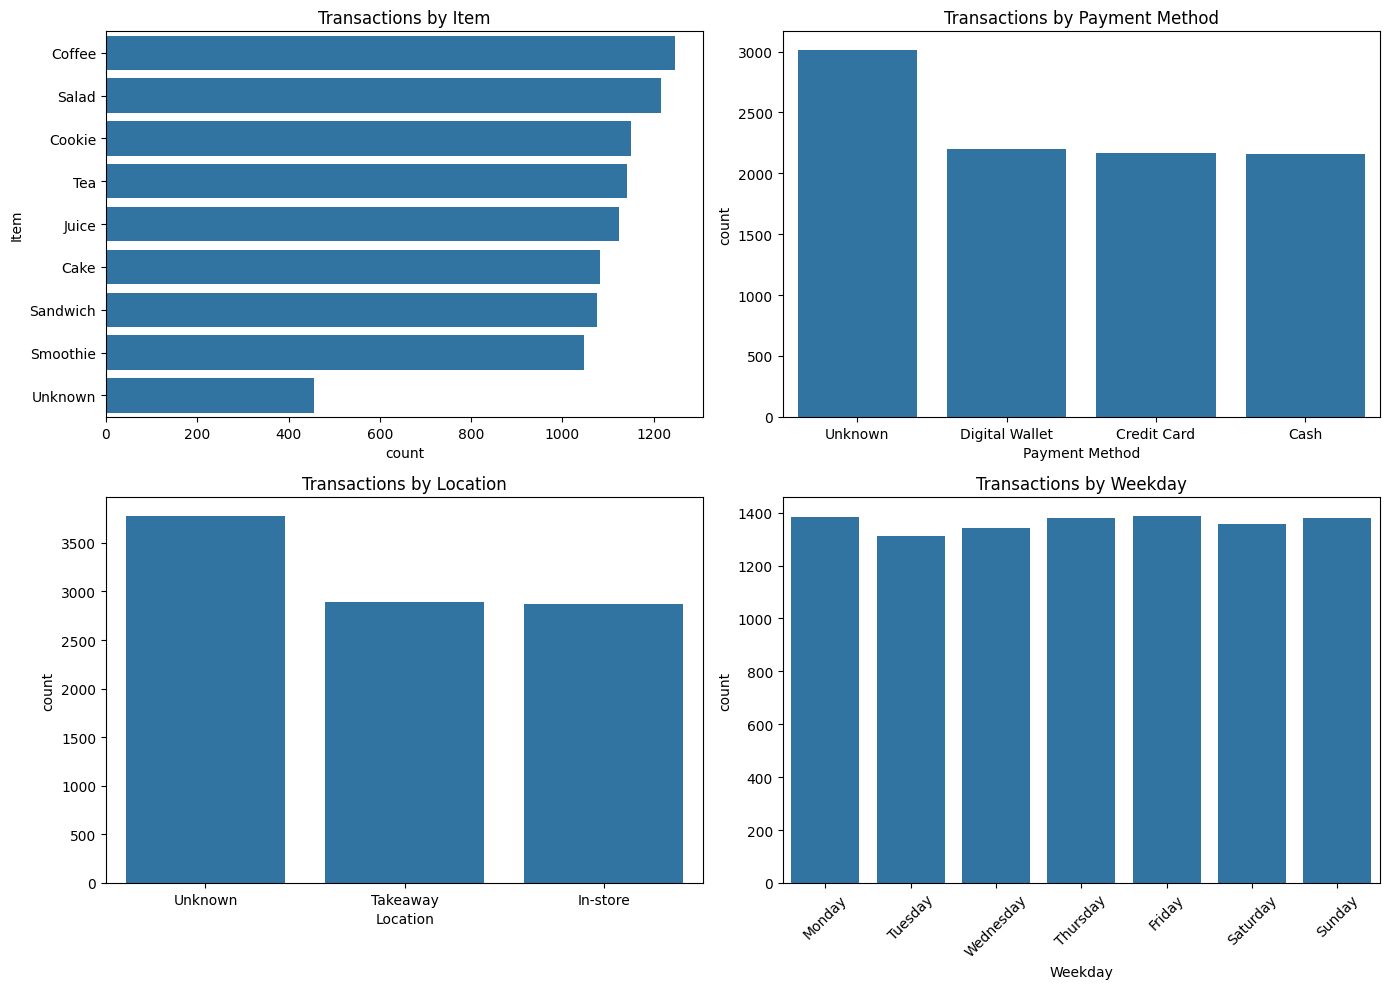

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, y="Item", order=df["Item"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Transactions by Item")

sns.countplot(data=df, x="Payment Method", order=df["Payment Method"].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title("Transactions by Payment Method")

sns.countplot(data=df, x="Location", order=df["Location"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Transactions by Location")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=df, x="Weekday", order=weekday_order, ax=axes[1, 1])
axes[1, 1].set_title("Transactions by Weekday")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 14. Outlier Checks

Boxplots flag extreme values visually; the IQR rule (`q1 - 1.5*iqr` to `q3 + 1.5*iqr`) quantifies how many `Total Spent` values count as statistical outliers.

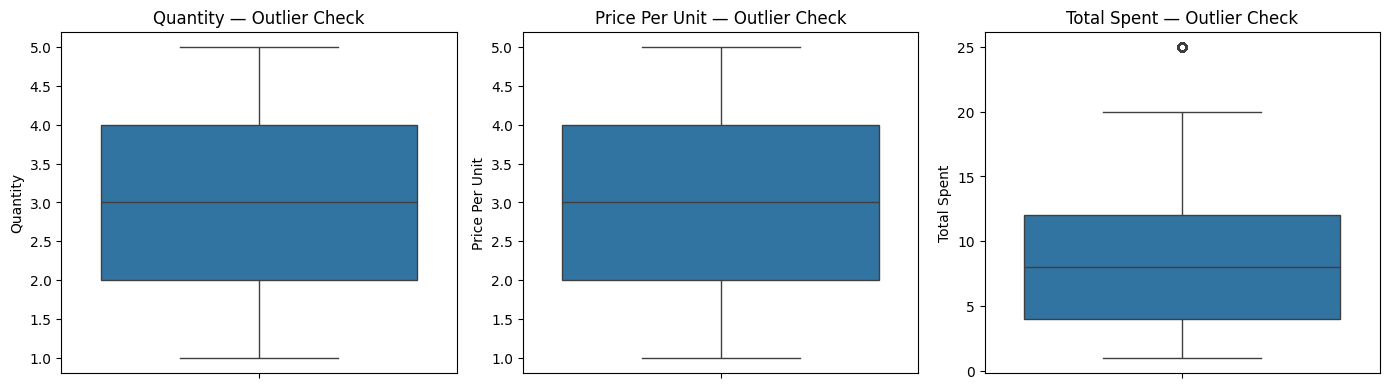

Total Spent outliers (IQR method): 259 rows


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"{col} — Outlier Check")
plt.tight_layout()
plt.show()

q1, q3 = df["Total Spent"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df["Total Spent"] < lower) | (df["Total Spent"] > upper)]
print(f"Total Spent outliers (IQR method): {len(outliers)} rows")

## 15. Bivariate — Total Spent by Item

Compares the spread of `Total Spent` across items — reveals which items tend to produce bigger transactions, not just more of them.

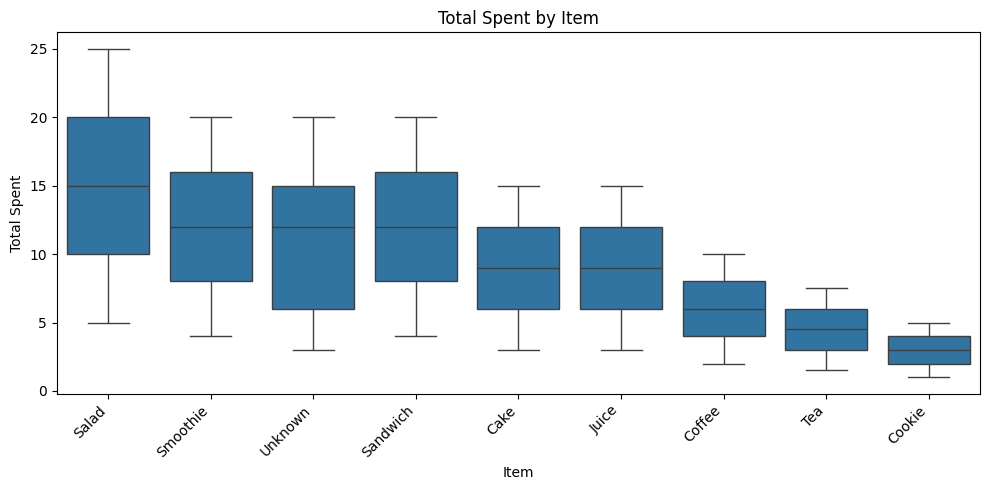

In [16]:
plt.figure(figsize=(10, 5))
order = df.groupby("Item")["Total Spent"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Item", y="Total Spent", order=order)
plt.title("Total Spent by Item")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Bivariate — Total Spent by Payment Method & Location

Same idea, split by payment method and location, to check whether either factor correlates with transaction size.

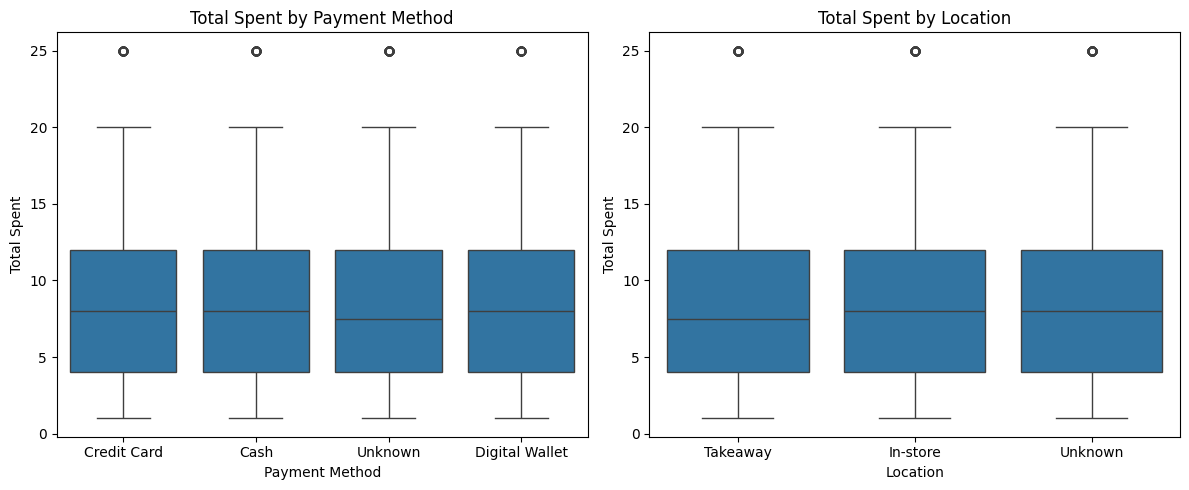

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="Payment Method", y="Total Spent", ax=axes[0])
axes[0].set_title("Total Spent by Payment Method")
sns.boxplot(data=df, x="Location", y="Total Spent", ax=axes[1])
axes[1].set_title("Total Spent by Location")
plt.tight_layout()
plt.show()

## 17. Revenue & Orders by Item

Builds a per-item summary table — order count, total revenue, and average order value — the core "which products matter" view.

          orders  revenue  avg_order_value
Item                                      
Salad       1216  18250.0        15.008224
Sandwich    1075  13116.0        12.200930
Smoothie    1048  12800.0        12.213740
Juice       1124  10050.0         8.941281
Cake        1082   9843.0         9.097043
Coffee      1246   7562.0         6.069021
Tea         1142   5166.0         4.523643
Unknown      456   4884.0        10.710526
Cookie      1151   3433.0         2.982624


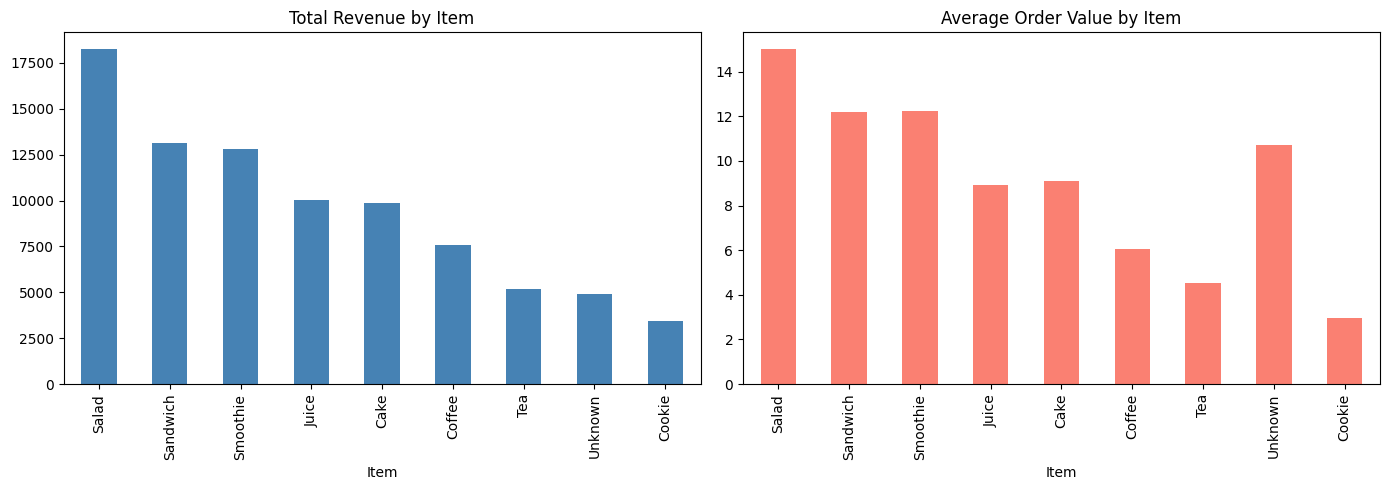

In [18]:
item_summary = (
    df.groupby("Item")
      .agg(orders=("Transaction ID", "count"), revenue=("Total Spent", "sum"),
           avg_order_value=("Total Spent", "mean"))
      .sort_values("revenue", ascending=False)
)
print(item_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
item_summary["revenue"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Revenue by Item")
item_summary["avg_order_value"].plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Average Order Value by Item")
plt.tight_layout()
plt.show()

## 18. Time Series — Daily Transactions & Revenue

Groups by calendar date to show day-to-day transaction volume and revenue, useful for spotting volatility or gaps.

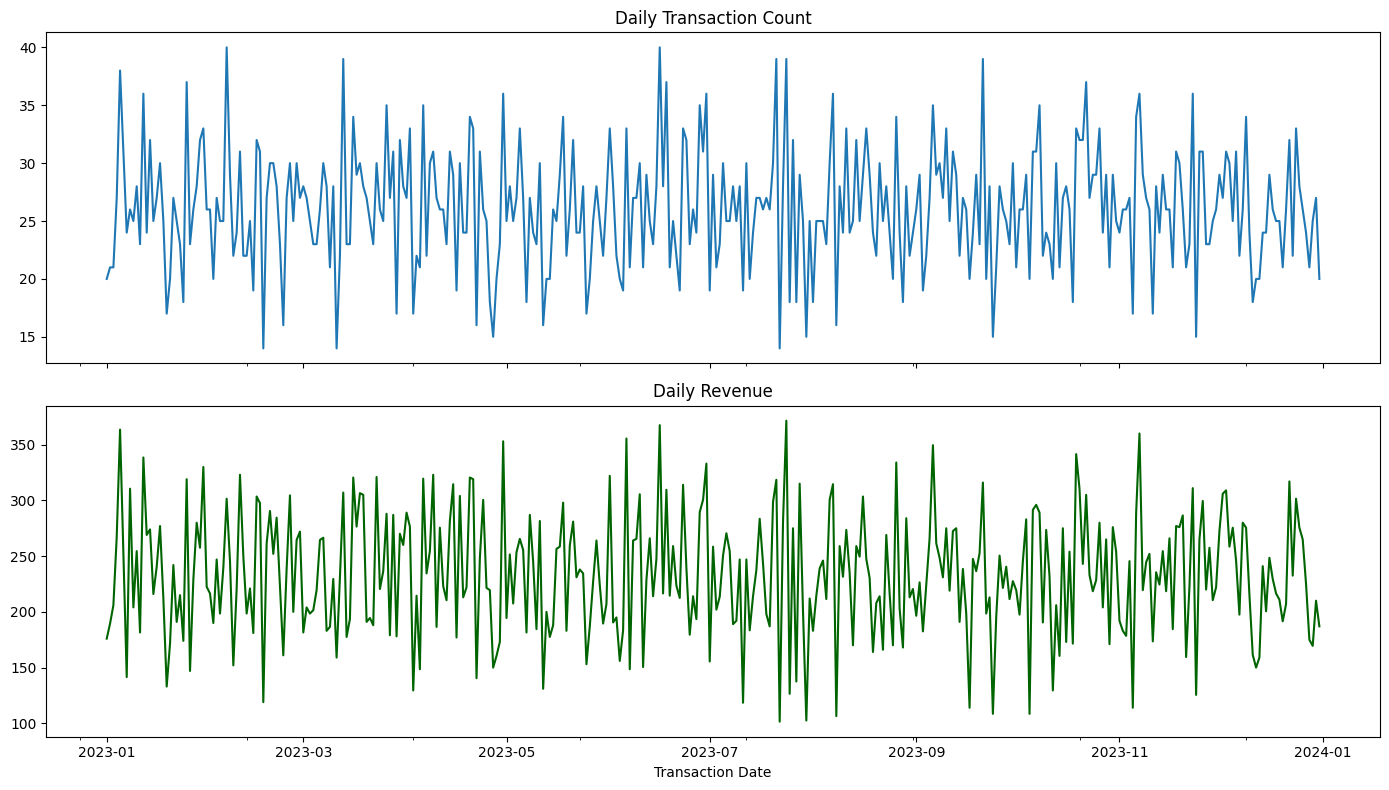

In [19]:
daily = df.groupby(df["Transaction Date"].dt.date).agg(
    transactions=("Transaction ID", "count"), revenue=("Total Spent", "sum")
)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
daily["transactions"].plot(ax=axes[0])
axes[0].set_title("Daily Transaction Count")
daily["revenue"].plot(ax=axes[1], color="darkgreen")
axes[1].set_title("Daily Revenue")
plt.tight_layout()
plt.show()

## 19. Monthly Revenue Trend & Month-over-Month Growth

`pct_change()` converts absolute monthly revenue into a growth rate, making trend direction and volatility easier to read.

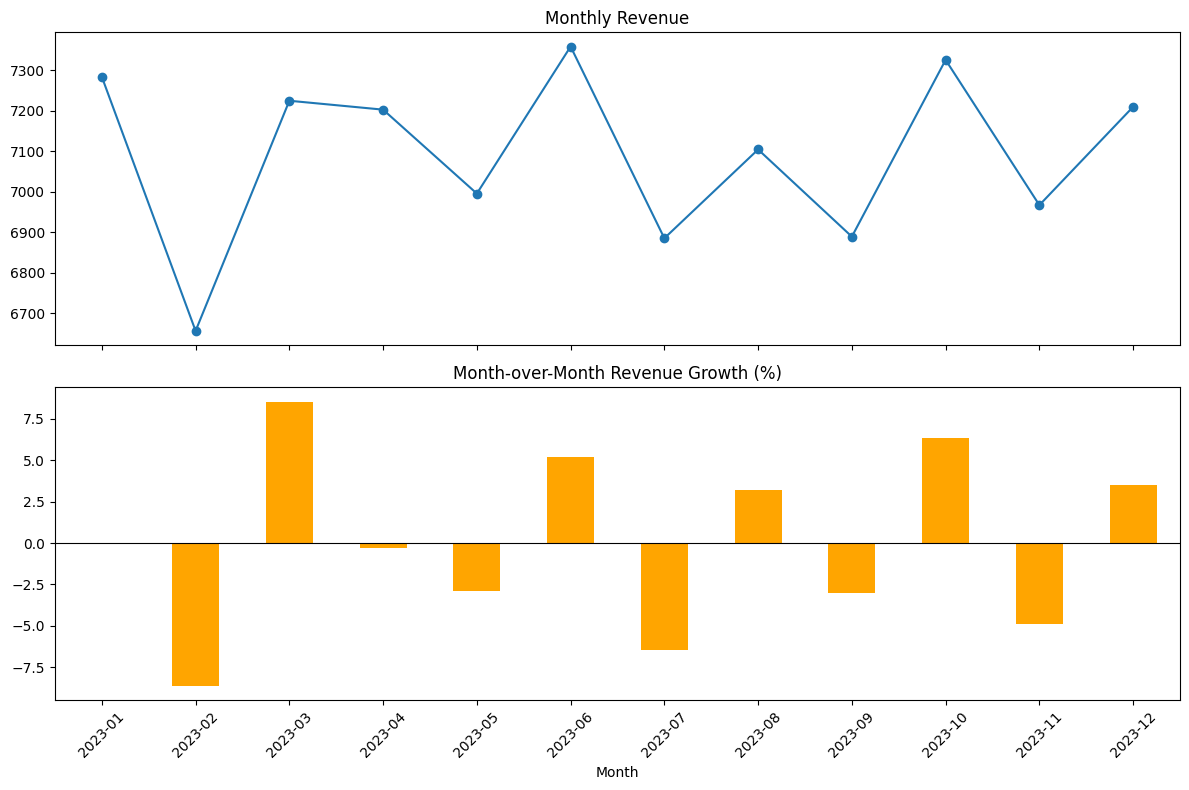

In [20]:
monthly = df.groupby("Month")["Total Spent"].sum().sort_index()
monthly_growth = monthly.pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
monthly.plot(kind="line", marker="o", ax=axes[0])
axes[0].set_title("Monthly Revenue")
monthly_growth.plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("Month-over-Month Revenue Growth (%)")
axes[1].axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Revenue by Weekday

Total revenue aggregated per weekday (ordered Monday–Sunday) to spot weekly patterns.

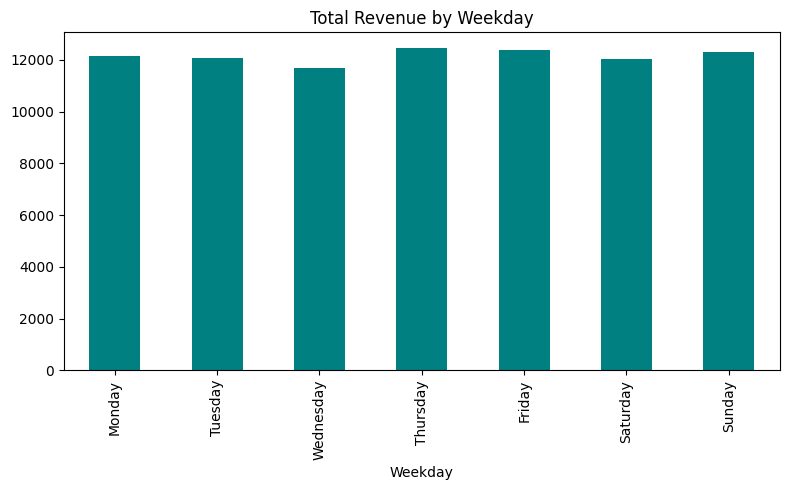

In [21]:
weekday_revenue = df.groupby("Weekday")["Total Spent"].sum().reindex(weekday_order)
plt.figure(figsize=(8, 5))
weekday_revenue.plot(kind="bar", color="teal")
plt.title("Total Revenue by Weekday")
plt.tight_layout()
plt.show()

## 21. Heatmaps — Item × Weekday, Payment Method × Location

Cross-tabulations rendered as color-coded grids — a compact way to see two-variable interactions at once.

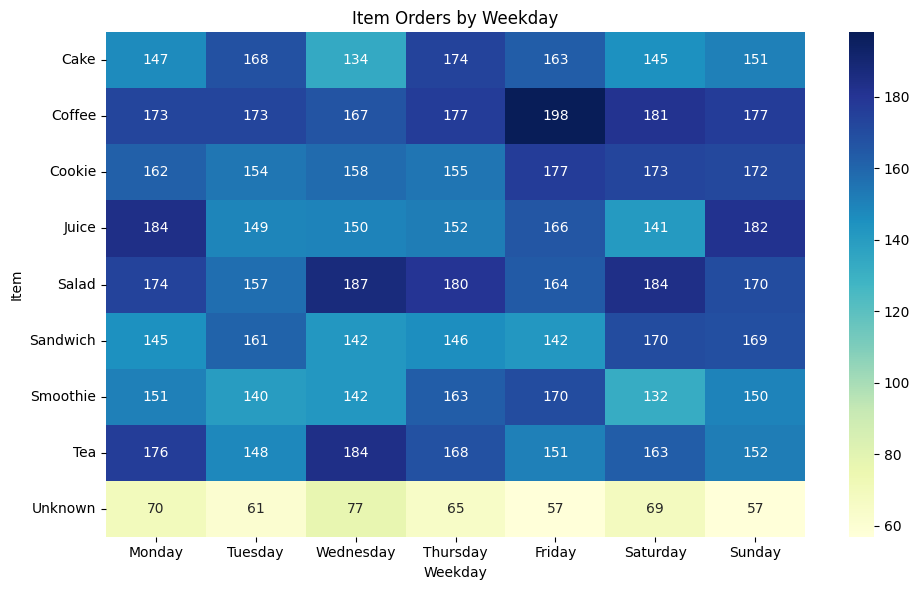

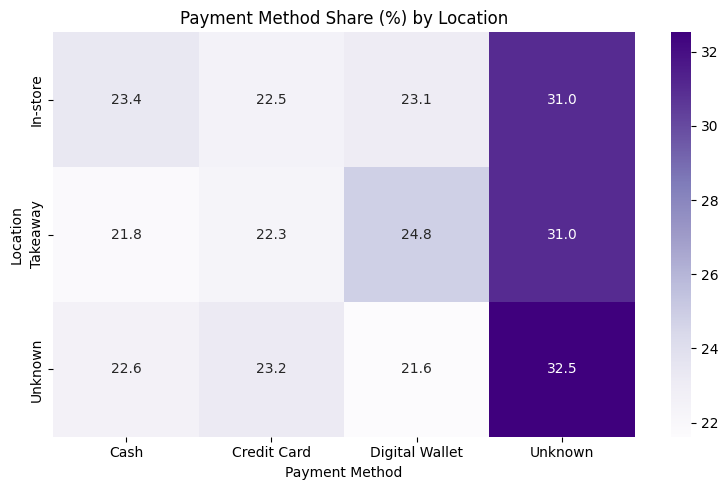

In [22]:
pivot_item_weekday = pd.crosstab(df["Item"], df["Weekday"])[weekday_order]
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_item_weekday, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Item Orders by Weekday")
plt.tight_layout()
plt.show()

pivot_pay_loc = pd.crosstab(df["Location"], df["Payment Method"], normalize="index") * 100
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_pay_loc, annot=True, fmt=".1f", cmap="Purples")
plt.title("Payment Method Share (%) by Location")
plt.tight_layout()
plt.show()

## 22. Correlation Matrix

Numeric correlation between Quantity, Price, and Total Spent. Expect strong correlation with Total Spent since it's derived from the other two — mostly a consistency check.

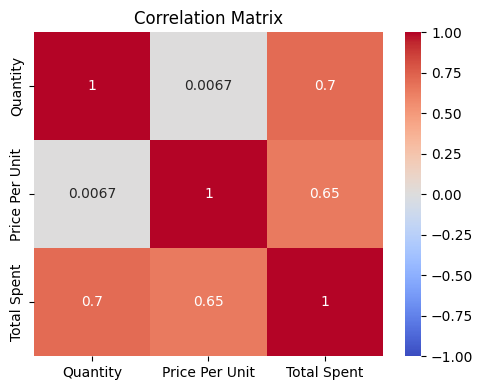

In [23]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 23. Scatter — Quantity vs Total Spent by Item

Shows how quantity and spend relate, colored by item, to see if certain items cluster into specific price/quantity combinations.

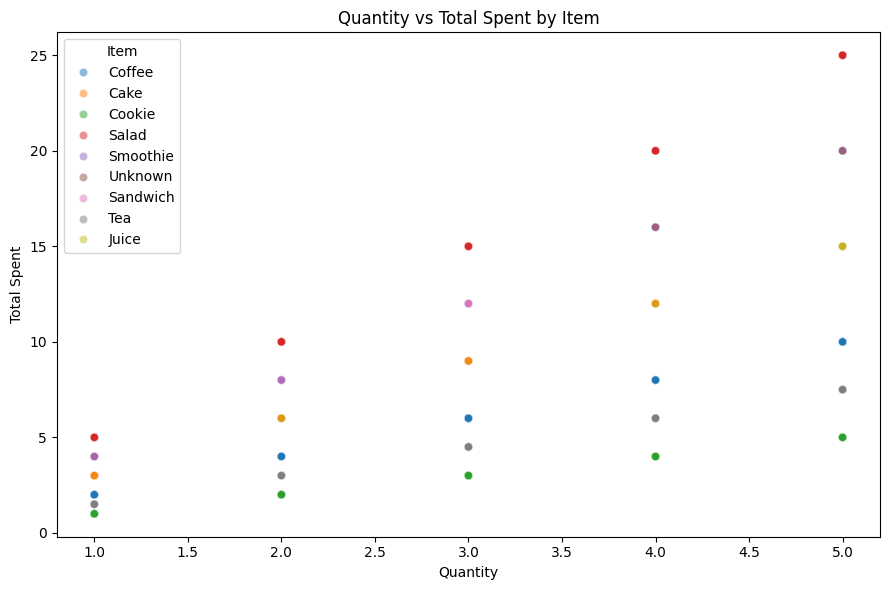

In [24]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Quantity", y="Total Spent", hue="Item", alpha=0.5)
plt.title("Quantity vs Total Spent by Item")
plt.tight_layout()
plt.show()

## 24. Basket Size Distribution

Count plot of how many units are typically bought per transaction.

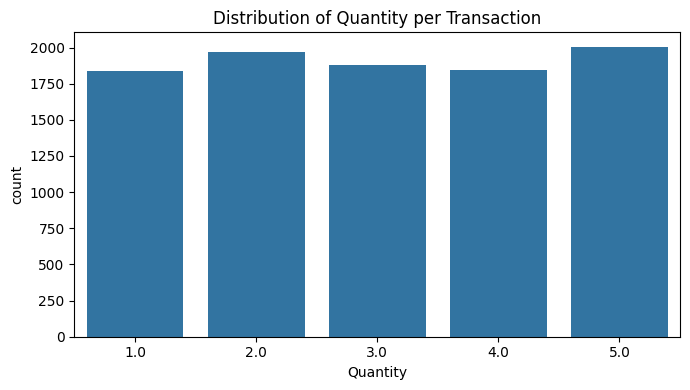

In [25]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Quantity")
plt.title("Distribution of Quantity per Transaction")
plt.tight_layout()
plt.show()

## 25. Average Order Value by Month & Location

Tracks whether spending behavior differs by location over time — e.g., seasonal patterns unique to one location.

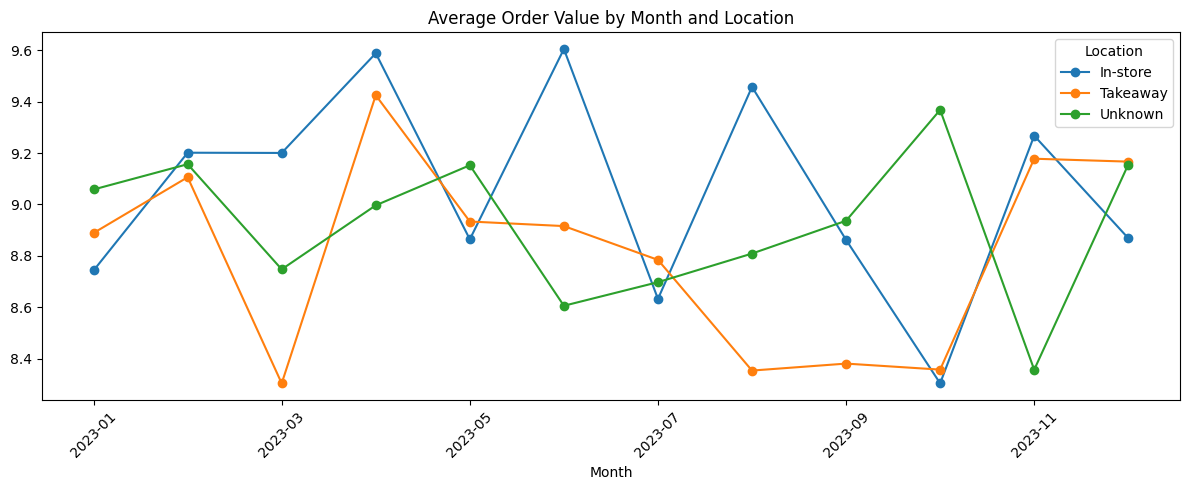

In [26]:
aov_by_month_loc = df.groupby(["Month", "Location"])["Total Spent"].mean().unstack()
plt.figure(figsize=(12, 5))
aov_by_month_loc.plot(marker="o", ax=plt.gca())
plt.title("Average Order Value by Month and Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 26. Key Insights Summary

Pulls single-number takeaways (top item, busiest weekday, peak month, etc.) into a readable printout.

**Note:** after cleaning, `"Unknown"` is the most common `Payment Method` and `Location` value (~30–40% of rows) — a genuine data-quality limitation worth stating explicitly, not a coding error.

In [27]:
print("          KEY EDA INSIGHTS"
      "\n------------------------------------")
print(f"Total transactions: {len(df):,}")
print(f"Total revenue: {df['Total Spent'].sum():,.2f}")
print(f"Average order value: {df['Total Spent'].mean():.2f}")
print(f"Best-selling item (by orders): {df['Item'].value_counts().idxmax()}")
print(f"Top revenue item: {item_summary['revenue'].idxmax()} ({item_summary['revenue'].max():,.2f})")
print(f"Busiest weekday: {weekday_revenue.idxmax()}")
print(f"Most common payment method: {df['Payment Method'].value_counts().idxmax()}")
print(f"Most common location: {df['Location'].value_counts().idxmax()}")
print(f"Peak revenue month: {monthly.idxmax()} ({monthly.max():,.2f})")

          KEY EDA INSIGHTS
------------------------------------
Total transactions: 9,540
Total revenue: 85,104.00
Average order value: 8.92
Best-selling item (by orders): Coffee
Top revenue item: Salad (18,250.00)
Busiest weekday: Thursday
Most common payment method: Unknown
Most common location: Unknown
Peak revenue month: 2023-06 (7,359.00)
